## Project 2

# Budget-Constrained Stock Selection with 0/1 Knapsack on S&P 500 Data

### MSML606
### Team Composition: Individual Project
### Author: Chenhongshu Yu
### UID: 116610971


## Statement

- The use of external resources is clearly cited. Please refer to the bold words in my submission.
- If no citation is found for any specific part of my submission, it means no external sources were used; all ideas are my own or from course lecture slides.
- The core logic and initial approach are manually authored and typed by the author Chenhongshu Yu.
- This notebook is an educational algorithm project, not financial advice.


## Problem and Motivation

The U.S. stock market gives investors many possible choices, but too many choices can make decision-making difficult. Some stocks may look attractive because their prices have recently increased, while other stocks may be less appealing because their prices are unstable. In real life, an investor usually cannot select every promising stock, because doing so may create a portfolio with too much risk.

The motivation for this project is to turn that everyday investing problem into a clear algorithm problem. Instead of asking someone to manually compare hundreds of stocks, this project uses recent price data to score each stock and then uses an optimization algorithm to select a balanced group of stocks.

The main question is:

**Which group of stocks gives the strongest recent momentum while staying under a fixed risk budget?**

This matters because the best-looking individual stocks are not always the best group when risk is limited. A portfolio is a combination decision: one very strong but very volatile stock might use too much of the risk budget, while several slightly less exciting stocks may fit together better.

To make the problem solvable, each stock is treated like one item in a backpack:

- The stock's **value** is its recent momentum score.
- The stock's **weight** is its recent volatility, converted into whole-number risk points.
- The **backpack limit** is the total risk budget.

Because each stock can either be selected or not selected, this becomes a **0/1 knapsack** problem. The algorithm helps find the best combination of stocks under the chosen risk limit.


## Dataset

Dataset: **Kaggle S&P 500 historical data**

https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data

The file used here is `SP500_Historical_Data.csv`. It contains daily stock prices for S&P 500 companies, including ticker, date, open, high, low, close, adjusted close, and volume.

I use adjusted closing prices because they are better for comparing price movement over time after stock splits and dividends.


## Algorithm

For each stock on the decision date, I compute:

**Momentum value**

$$
v_i=\max\left(0,\;0.6r_{5,i}+0.4r_{20,i}\right)
$$

where `r5` is the 5-trading-day return and `r20` is the 20-trading-day return. Negative momentum becomes 0, so the algorithm only considers stocks with positive recent momentum.

**Risk weight**

The stock's risk weight is its 20-trading-day volatility. Since dynamic programming needs whole-number capacity units, volatility is converted into **risk points**:

$$
\text{risk points}=\lceil \text{volatility}\times 10000\rceil
$$

Example: a stock with 1.50% daily volatility costs about 150 risk points.

**Optimization goal**

$$
\max \sum_i v_i x_i
$$

subject to:

$$
\sum_i w_i x_i \le W
$$

where `x_i` is 1 if the stock is selected and 0 otherwise.


## Setup

The core algorithm code lives in `portfolio_knapsack.py`. The notebook below loads the data, builds the stock candidates, runs the exact dynamic programming solution, compares it to a greedy baseline, and shows the results in tables and charts.


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from portfolio_knapsack import (
    all_market_dates,
    build_candidates,
    choose_decision_date,
    compare_across_capacities,
    load_stock_history,
    solve_knapsack_dp,
    solve_knapsack_greedy,
    summarize_candidates,
)

DATA_PATH = Path("SP500_Historical_Data.csv")
FUTURE_DAYS = 20
RISK_SCALE = 10_000
CAPACITY_POINTS = 3_000

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)

## Load the S&P 500 Price History

To keep the demonstration honest, the algorithm chooses stocks using only information available on the decision date. Then I look at the next 20 trading days only as a simple holdout check.


In [2]:
history = load_stock_history(DATA_PATH)
market_dates = all_market_dates(history)
decision_date = choose_decision_date(history, future_days=FUTURE_DAYS)
latest_dataset_date = market_dates[-1]

dataset_summary = pd.DataFrame(
    [
        {"Question": "How many tickers are in the file?", "Answer": f"{len(history):,}"},
        {"Question": "First date in the file", "Answer": market_dates[0]},
        {"Question": "Last date in the file", "Answer": latest_dataset_date},
        {"Question": "Decision date used by the algorithm", "Answer": decision_date},
        {"Question": "Holdout window", "Answer": f"Next {FUTURE_DAYS} trading days"},
    ]
)

display(dataset_summary)

,Question,Answer
0,How many tickers are in the file?,472
1,First date in the file,2000-01-03
2,Last date in the file,2026-02-20
3,Decision date used by the algorithm,2026-01-22
4,Holdout window,Next 20 trading days


## Build the Stock Candidates

Each candidate stock needs three pieces of information:

- recent momentum score, which the optimizer tries to maximize;
- recent volatility, which becomes the risk cost;
- next 20-trading-day return, used only after the selection to see what happened next.


In [ ]:
candidates = build_candidates(
    history,
    decision_date,
    future_days = FUTURE_DAYS,
    risk_scale = RISK_SCALE,
    require_positive_momentum = True,
    require_future_return = True,
)

candidate_summary = summarize_candidates(candidates)
summary_table = pd.DataFrame(
    [
        {"Metric": "Candidate stocks with positive momentum", "Value": f"{candidate_summary['candidate_count']:,}"},
        {"Metric": "Average momentum score", "Value": f"{candidate_summary['average_momentum']:.2%}"},
        {"Metric": "Average 20-day volatility", "Value": f"{candidate_summary['average_volatility']:.2%}"},
        {"Metric": "Average risk points", "Value": f"{candidate_summary['average_risk_points']:.1f}"},
        {"Metric": "Risk budget used in main run", "Value": f"{CAPACITY_POINTS:,} points"},
    ]
)

display(summary_table)

,Metric,Value
0,Candidate stocks with positive momentum,290
1,Average momentum score,4.70%
2,Average 20-day volatility,1.73%
3,Average risk points,173.9
4,Risk budget used in main run,"3,000 points"


In [ ]:
def stock_table(stocks):
    rows = []
    for stock in stocks:
        rows.append(
            {
                "Ticker": stock.ticker,
                "Price": f"${stock.price:,.2f}",
                "5-day return": f"{stock.return_5d:.2%}",
                "20-day return": f"{stock.return_20d:.2%}",
                "Momentum score": f"{stock.momentum_value:.2%}",
                "20-day volatility": f"{stock.volatility_20d:.2%}",
                "Risk points": stock.risk_points,
                "Next 20-day return": "n/a" if stock.future_return_20d is None else f"{stock.future_return_20d:.2%}",
            }
        )
    return pd.DataFrame(rows)

top_momentum_stocks = sorted(candidates, key = lambda stock: stock.momentum_value, reverse = True)[:10]
display(stock_table(top_momentum_stocks))

,Ticker,Price,5-day return,20-day return,Momentum score,20-day volatility,Risk points,Next 20-day return
0,SNDK,$503.44,29.82%,108.85%,61.43%,7.58%,759,29.11%
1,MU,$397.58,19.27%,43.80%,29.08%,4.09%,409,7.69%
2,INTC,$54.32,11.49%,49.35%,26.64%,4.28%,429,-18.80%
3,WDC,$243.29,13.16%,37.64%,22.95%,5.45%,545,17.36%
4,GNRC,$175.34,9.41%,25.20%,15.73%,2.37%,237,30.71%
5,STX,$346.53,10.97%,22.84%,15.71%,4.63%,464,18.64%
6,ENPH,$40.48,12.04%,20.84%,15.56%,3.51%,351,15.02%
7,ALB,$188.32,6.07%,29.54%,15.45%,3.39%,339,-10.57%
8,AMD,$253.73,13.47%,18.04%,15.30%,2.66%,267,-21.12%
9,SLB,$49.03,5.01%,28.65%,14.47%,2.64%,265,3.71%


## Solve the Portfolio Selection Problem

I solve the same stock-selection problem two ways:

- **Dynamic programming:** checks combinations systematically and gives the exact best answer for this simplified model.
- **Greedy baseline:** sorts stocks by momentum per risk point and keeps taking the best-looking stock that still fits.

The greedy method is easier to explain, but it can miss a better combination. The dynamic programming method is the main algorithm for this project.


In [5]:
dp_result = solve_knapsack_dp(candidates, CAPACITY_POINTS)
greedy_result = solve_knapsack_greedy(candidates, CAPACITY_POINTS)

comparison_table = pd.DataFrame(
    [
        {
            "Method": "Dynamic programming",
            "Stocks selected": len(dp_result.selected),
            "Risk used": f"{dp_result.total_risk_points:,} / {CAPACITY_POINTS:,}",
            "Total momentum score": f"{dp_result.total_value:.2%}",
            "Next 20-day avg return": f"{dp_result.average_future_return:.2%}",
        },
        {
            "Method": "Greedy baseline",
            "Stocks selected": len(greedy_result.selected),
            "Risk used": f"{greedy_result.total_risk_points:,} / {CAPACITY_POINTS:,}",
            "Total momentum score": f"{greedy_result.total_value:.2%}",
            "Next 20-day avg return": f"{greedy_result.average_future_return:.2%}",
        },
    ]
)

display(comparison_table)

,Method,Stocks selected,Risk used,Total momentum score,Next 20-day avg return
0,Dynamic programming,11,"2,998 / 3,000",211.00%,6.52%
1,Greedy baseline,13,"3,000 / 3,000",210.45%,4.09%


## Dynamic Programming Portfolio

The table below shows the stock basket chosen by the exact dynamic programming algorithm. The algorithm is not trying to predict the future perfectly. It is solving a narrower question: among the available stocks, which combination has the highest recent momentum score while staying under the chosen risk budget?


In [ ]:
dp_selected = sorted(dp_result.selected, key = lambda stock: stock.momentum_value, reverse=True)
display(stock_table(dp_selected))

,Ticker,Price,5-day return,20-day return,Momentum score,20-day volatility,Risk points,Next 20-day return
0,SNDK,$503.44,29.82%,108.85%,61.43%,7.58%,759,29.11%
1,MU,$397.58,19.27%,43.80%,29.08%,4.09%,409,7.69%
2,INTC,$54.32,11.49%,49.35%,26.64%,4.28%,429,-18.80%
3,GNRC,$175.34,9.41%,25.20%,15.73%,2.37%,237,30.71%
4,BG,$112.66,6.83%,25.47%,14.28%,1.77%,177,8.25%
5,BKR,$54.46,8.96%,19.53%,13.19%,2.15%,215,14.23%
6,WHR,$89.66,5.17%,23.79%,12.62%,1.96%,196,-5.77%
7,FMC,$16.02,5.81%,22.29%,12.40%,1.80%,180,-8.74%
8,ARE,$58.09,3.47%,21.25%,10.58%,1.48%,148,-7.64%
9,KMI,$29.40,7.81%,10.40%,8.85%,1.48%,149,11.33%


## Does the Risk Budget Matter?

A smaller budget creates a stricter portfolio. A larger budget allows the optimizer to select more total volatility. The table below reruns both methods across several budgets.


In [7]:
capacities = [500, 800, 1_000, 1_200, 1_500, 2_000, 3_000]
capacity_results = compare_across_capacities(candidates, capacities)

capacity_table = pd.DataFrame(
    [
        {
            "Risk budget": f"{row['Risk budget']:,}",
            "DP stocks": row["DP stocks"],
            "DP risk used": f"{row['DP risk used']:,}",
            "DP momentum": f"{row['DP momentum']:.2%}",
            "Greedy stocks": row["Greedy stocks"],
            "Greedy risk used": f"{row['Greedy risk used']:,}",
            "Greedy momentum": f"{row['Greedy momentum']:.2%}",
            "DP advantage": f"{row['DP momentum advantage']:.2%}",
        }
        for row in capacity_results
    ]
)

display(capacity_table)


,Risk budget,DP stocks,DP risk used,DP momentum,Greedy stocks,Greedy risk used,Greedy momentum,DP advantage
0,500,3,494,35.35%,5,499,34.54%,0.80%
1,800,3,793,61.99%,3,793,61.99%,0.00%
2,"1,000",3,995,78.70%,3,995,78.70%,0.00%
3,"1,200",4,"1,200",93.13%,5,"1,199",92.98%,0.15%
4,"1,500",4,"1,493",115.38%,4,"1,493",115.38%,0.00%
5,"2,000",7,"1,991",147.93%,8,"1,985",146.99%,0.94%
6,"3,000",11,"2,998",211.00%,13,"3,000",210.45%,0.55%


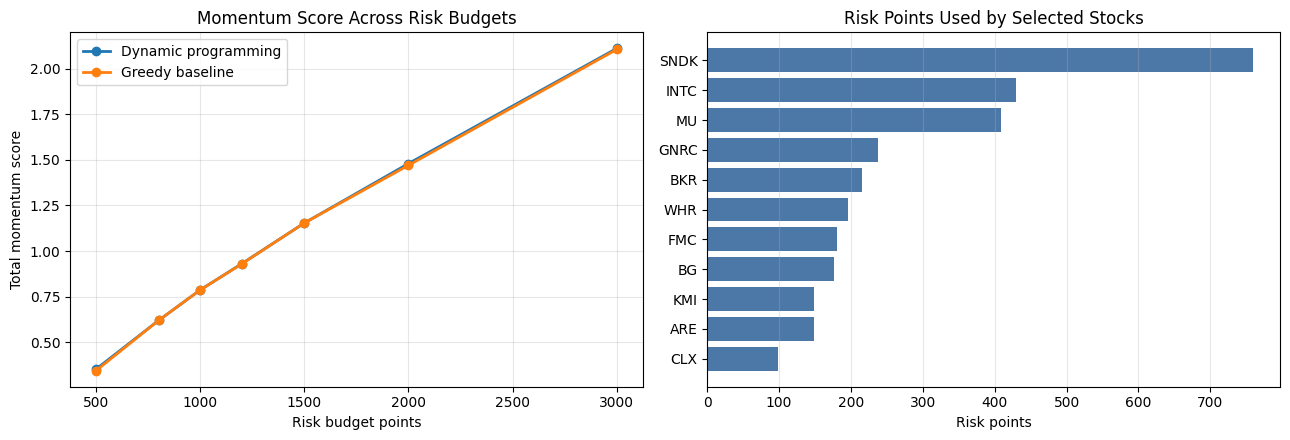

In [ ]:
budgets = [row["Risk budget"] for row in capacity_results]
dp_scores = [row["DP momentum"] for row in capacity_results]
greedy_scores = [row["Greedy momentum"] for row in capacity_results]

fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

axes[0].plot(budgets, dp_scores, marker = "o", linewidth = 2, label = "Dynamic programming")
axes[0].plot(budgets, greedy_scores, marker = "o", linewidth = 2, label = "Greedy baseline")
axes[0].set_title("Momentum Score Across Risk Budgets")
axes[0].set_xlabel("Risk budget points")
axes[0].set_ylabel("Total momentum score")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

selected_for_plot = sorted(dp_result.selected, key = lambda stock: stock.risk_points)
axes[1].barh(
    [stock.ticker for stock in selected_for_plot],
    [stock.risk_points for stock in selected_for_plot],
    color="#4C78A8",
)
axes[1].set_title("Risk Points Used by Selected Stocks")
axes[1].set_xlabel("Risk points")
axes[1].grid(True, axis = "x", alpha = 0.3)

plt.tight_layout()
plt.show()


## Result Summary for a Non-CS Audience

The dynamic programming portfolio is the best basket under the simplified rules of this project: it gives the highest total momentum score without going over the risk budget. The greedy baseline is useful because it is intuitive, but it only looks at the next best stock one at a time. Dynamic programming is stronger because it compares combinations of stocks.

The 20-trading-day holdout result is included as a reality check, not as a promise. The algorithm did not know those future returns when it selected the portfolio. In a real investing setting, this model would need more risk controls, transaction costs, sector limits, and repeated testing across many dates.
